In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from prophet import Prophet
import sqlite3
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Load directly from original raw CSV
df = pd.read_csv('../data/raw/retail_store_inventory.csv')
df.columns = [c.strip().lower().replace(' ', '_').replace('/', '_') for c in df.columns]
df['date'] = pd.to_datetime(df['date'])

# Save clean version now so Phase 4 can use it
df.to_csv('../data/processed/freshmart_clean.csv', index=False)

# Save to DB too
DB_PATH = '../data/processed/freshmart.db'
conn = sqlite3.connect(DB_PATH)
df.to_sql('clean_inventory', conn, if_exists='replace', index=False)
conn.close()

print(f"✅ Loaded: {df.shape[0]:,} rows")
print(f"✅ Clean CSV saved to data/processed/freshmart_clean.csv")
print(f"✅ Saved to database as clean_inventory table")
print(f"\nColumns: {df.columns.tolist()}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Categories: {df['category'].unique().tolist()}")

✅ Loaded: 73,100 rows
✅ Clean CSV saved to data/processed/freshmart_clean.csv
✅ Saved to database as clean_inventory table

Columns: ['date', 'store_id', 'product_id', 'category', 'region', 'inventory_level', 'units_sold', 'units_ordered', 'demand_forecast', 'price', 'discount', 'weather_condition', 'holiday_promotion', 'competitor_pricing', 'seasonality']
Date range: 2022-01-01 → 2024-01-01
Categories: ['Groceries', 'Toys', 'Electronics', 'Furniture', 'Clothing']


In [2]:
# Aggregate daily sales per category
daily_sales = df.groupby(['date', 'category']).agg(
    units_sold=('units_sold', 'sum'),
    avg_inventory=('inventory_level', 'mean'),
    avg_price=('price', 'mean')
).reset_index()

daily_sales = daily_sales.rename(columns={'date': 'ds', 'units_sold': 'y'})

print("Daily sales prepared for Prophet:")
print(f"Shape: {daily_sales.shape}")
print(f"\nSample:")
print(daily_sales.head(10).to_string(index=False))

categories = daily_sales['category'].unique().tolist()
print(f"\nCategories to forecast: {categories}")

Daily sales prepared for Prophet:
Shape: (3655, 5)

Sample:
        ds    category    y  avg_inventory  avg_price
2022-01-01    Clothing 3784         296.36      56.24
2022-01-01 Electronics 3440         292.23      56.44
2022-01-01   Furniture 1738         286.17      56.09
2022-01-01   Groceries 3112         308.35      62.49
2022-01-01        Toys 2410         235.67      55.35
2022-01-02    Clothing 2326         244.88      59.46
2022-01-02 Electronics 2555         272.00      54.65
2022-01-02   Furniture 2108         251.52      59.29
2022-01-02   Groceries 2817         276.11      59.99
2022-01-02        Toys 3609         311.23      69.11

Categories to forecast: ['Clothing', 'Electronics', 'Furniture', 'Groceries', 'Toys']


In [3]:
forecasts = {}
models    = {}

FORECAST_DAYS = 90  # forecast 90 days into the future

print("Training Prophet models...\n")

for cat in categories:
    cat_data = daily_sales[daily_sales['category'] == cat][['ds', 'y']].copy()
    cat_data = cat_data.sort_values('ds').reset_index(drop=True)

    # Build Prophet model
    model = Prophet(
        seasonality_mode='multiplicative',
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.05,    # controls trend flexibility
        seasonality_prior_scale=10,
    )
    model.add_seasonality(name='monthly', period=30.5, fourier_order=5)

    model.fit(cat_data)

    # Create future dataframe
    future = model.make_future_dataframe(periods=FORECAST_DAYS, freq='D')
    forecast = model.predict(future)

    forecasts[cat] = forecast
    models[cat]    = model

    # Key metrics
    last_actual   = cat_data['y'].iloc[-30:].mean()
    next_30_pred  = forecast[forecast['ds'] > cat_data['ds'].max()]['yhat'].head(30).mean()
    pct_change    = (next_30_pred - last_actual) / last_actual * 100

    print(f"✅ {cat:15s} | Avg last 30d: {last_actual:.0f} units | "
          f"Forecast next 30d: {next_30_pred:.0f} units | "
          f"Change: {pct_change:+.1f}%")

print("\n✅ All models trained successfully!")

Training Prophet models...



10:40:01 - cmdstanpy - INFO - Chain [1] start processing
10:40:02 - cmdstanpy - INFO - Chain [1] done processing


✅ Clothing        | Avg last 30d: 2500 units | Forecast next 30d: 2508 units | Change: +0.4%


10:40:03 - cmdstanpy - INFO - Chain [1] start processing
10:40:03 - cmdstanpy - INFO - Chain [1] done processing


✅ Electronics     | Avg last 30d: 2907 units | Forecast next 30d: 2723 units | Change: -6.3%


...

✅ Furniture       | Avg last 30d: 2850 units | Forecast next 30d: 2894 units | Change: +1.5%


10:40:05 - cmdstanpy - INFO - Chain [1] start processing
10:40:05 - cmdstanpy - INFO - Chain [1] done processing


✅ Groceries       | Avg last 30d: 2619 units | Forecast next 30d: 2649 units | Change: +1.2%


10:40:05 - cmdstanpy - INFO - Chain [1] start processing
10:40:05 - cmdstanpy - INFO - Chain [1] done processing


✅ Toys            | Avg last 30d: 2685 units | Forecast next 30d: 2708 units | Change: +0.9%

✅ All models trained successfully!


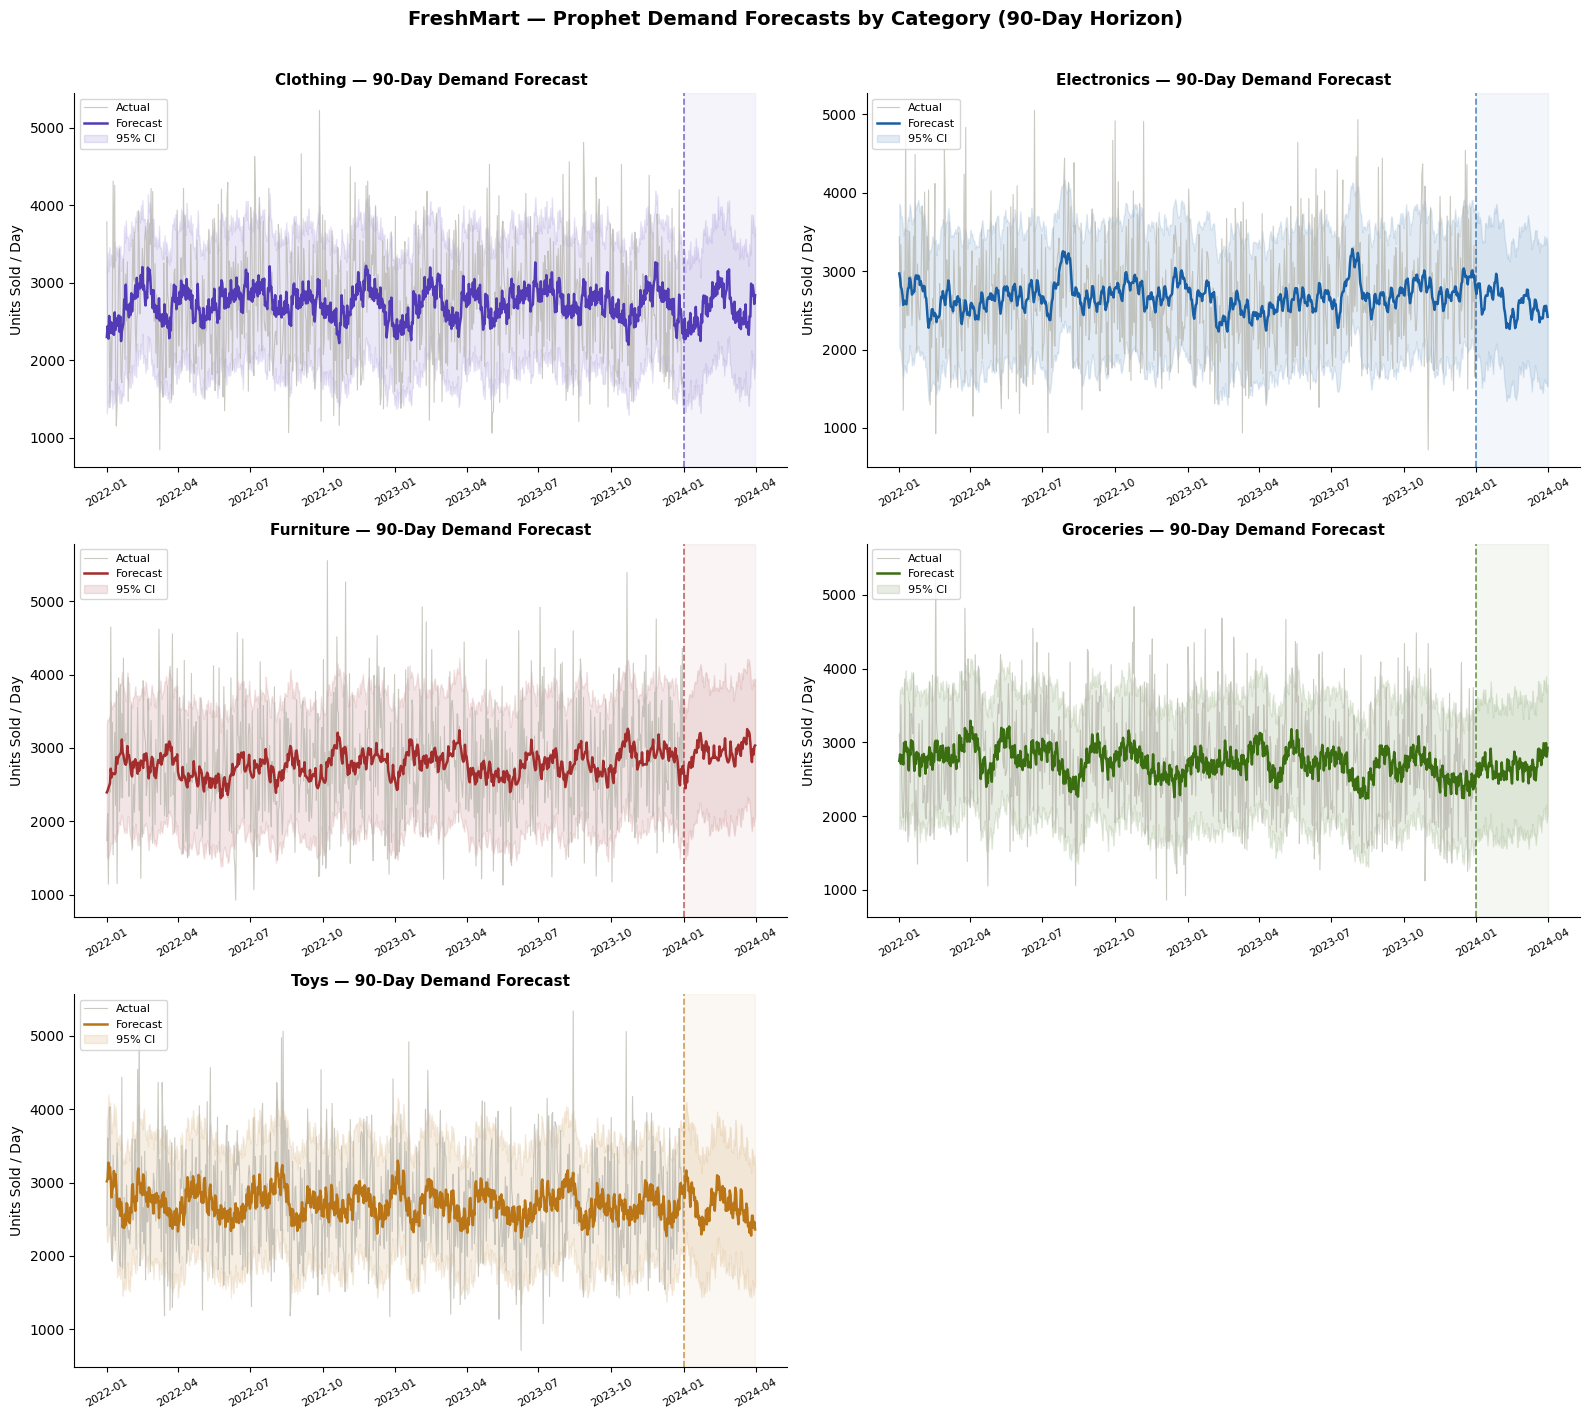

✅ Chart 6 saved


In [4]:
cat_colors = {
    'Electronics': '#185FA5',
    'Groceries':   '#3B6D11',
    'Clothing':    '#533AB7',
    'Toys':        '#BA7517',
    'Furniture':   '#A32D2D'
}

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, cat in enumerate(categories):
    ax = axes[i]
    cat_data = daily_sales[daily_sales['category'] == cat][['ds', 'y']].copy()
    fc       = forecasts[cat]
    color    = cat_colors.get(cat, '#444441')

    # Split into historical and future
    historical = fc[fc['ds'] <= cat_data['ds'].max()]
    future_fc  = fc[fc['ds'] >  cat_data['ds'].max()]

    # Plot actual
    ax.plot(cat_data['ds'], cat_data['y'],
            color='#B4B2A9', linewidth=0.8, alpha=0.7, label='Actual')

    # Plot forecast line
    ax.plot(fc['ds'], fc['yhat'],
            color=color, linewidth=1.8, label='Forecast')

    # Confidence interval
    ax.fill_between(fc['ds'], fc['yhat_lower'], fc['yhat_upper'],
                    color=color, alpha=0.12, label='95% CI')

    # Shade forecast period
    ax.axvspan(cat_data['ds'].max(), fc['ds'].max(),
               color=color, alpha=0.05)
    ax.axvline(x=cat_data['ds'].max(), color=color,
               linestyle='--', linewidth=1.2, alpha=0.7)

    ax.set_title(f'{cat} — 90-Day Demand Forecast', fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Units Sold / Day')
    ax.legend(fontsize=8, loc='upper left')
    ax.tick_params(axis='x', rotation=30, labelsize=8)

# Hide the 6th subplot (we have 5 categories)
axes[5].set_visible(False)

plt.suptitle('FreshMart — Prophet Demand Forecasts by Category (90-Day Horizon)',
             fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/output/chart6_demand_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 6 saved")

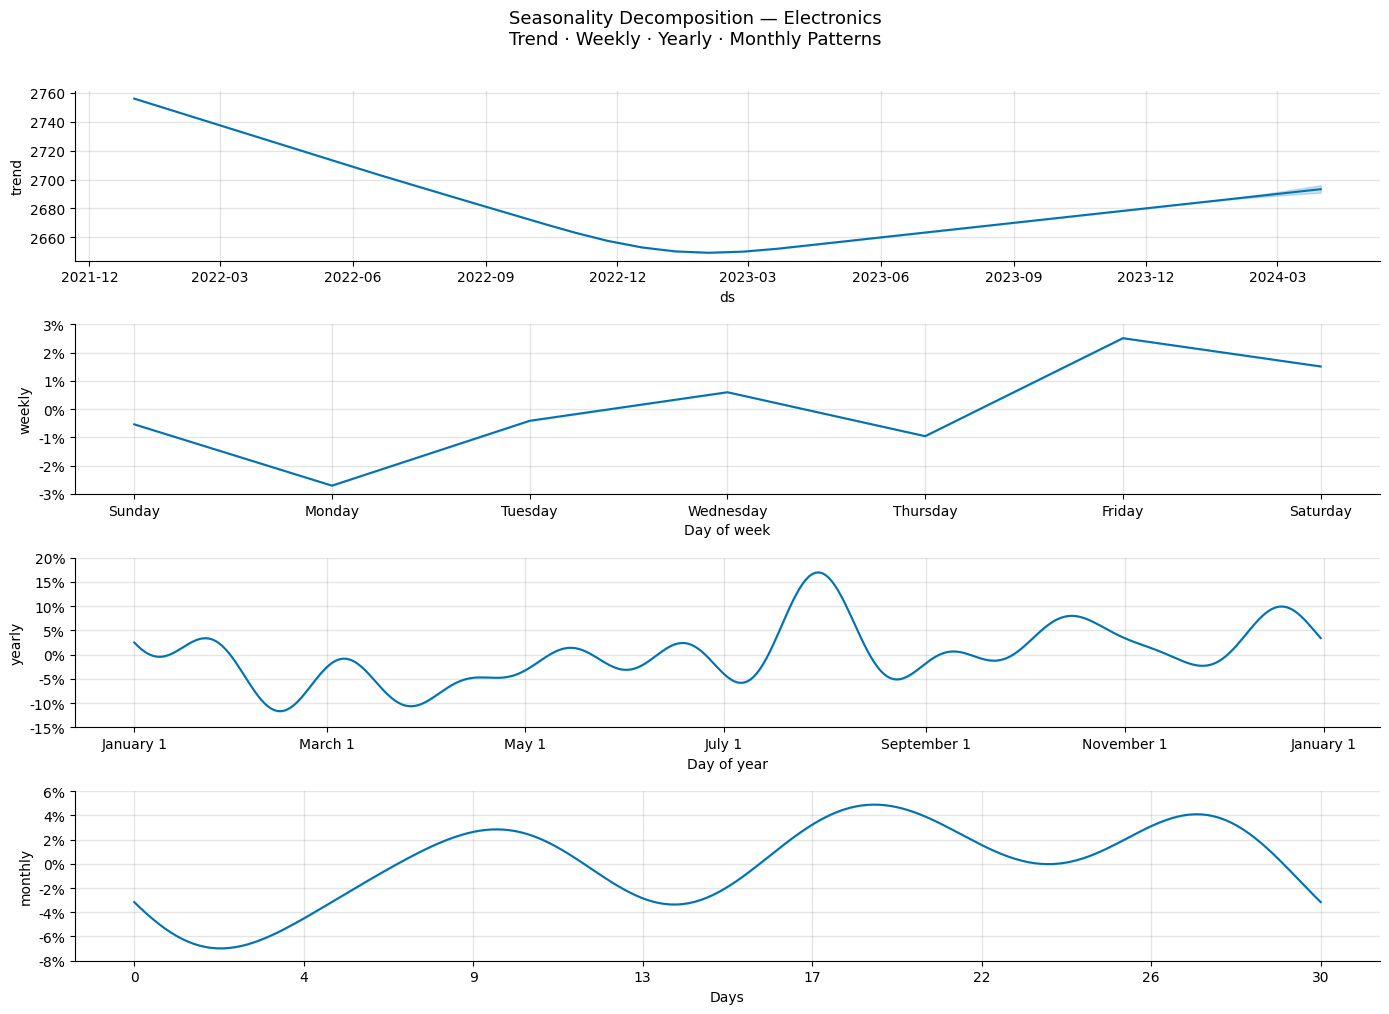

✅ Chart 7 saved


In [5]:
# Show seasonality components for Electronics (most interesting)
cat = 'Electronics'
model = models[cat]
fc    = forecasts[cat]

fig = model.plot_components(fc)
fig.set_size_inches(14, 10)
fig.suptitle(f'Seasonality Decomposition — {cat}\n'
             f'Trend · Weekly · Yearly · Monthly Patterns',
             fontsize=13, y=1.01)

plt.tight_layout()
plt.savefig('../data/output/chart7_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 7 saved")

In [6]:
# Business assumption: supplier lead time = 7 days
# Safety stock = 1.5x average daily demand (covers demand spikes)
LEAD_TIME_DAYS  = 7
SAFETY_STOCK_MULTIPLIER = 1.5

reorder_recommendations = []

for cat in categories:
    cat_data = daily_sales[daily_sales['category'] == cat].copy()
    fc       = forecasts[cat]

    # Historical avg daily demand
    avg_daily_demand = cat_data['y'].mean()

    # Forecasted avg daily demand (next 30 days)
    future_only = fc[fc['ds'] > cat_data['ds'].max()].head(30)
    forecast_daily_demand = future_only['yhat'].mean()

    # Reorder Point = (Avg Daily Demand × Lead Time) + Safety Stock
    safety_stock  = avg_daily_demand * SAFETY_STOCK_MULTIPLIER
    reorder_point = (avg_daily_demand * LEAD_TIME_DAYS) + safety_stock

    # Economic Order Quantity (EOQ) — simplified Wilson formula
    # EOQ = sqrt(2 × Annual Demand × Ordering Cost / Holding Cost per unit)
    annual_demand   = avg_daily_demand * 365
    ordering_cost   = 500    # Rs. 500 per order placed (assumption)
    holding_cost    = 50     # Rs. 50 per unit per year (assumption)
    eoq = np.sqrt((2 * annual_demand * ordering_cost) / holding_cost)

    # Current avg inventory from data
    current_stock = cat_data.merge(
        df.groupby('category')['inventory_level'].mean().reset_index(),
        left_on='category', right_on='category', how='left'
    )
    current_avg_stock = df[df['category'].str.lower() == cat.lower()]['inventory_level'].mean()

    reorder_recommendations.append({
        'Category':                  cat,
        'Avg Daily Demand (units)':  round(avg_daily_demand, 1),
        'Forecasted Daily Demand':   round(forecast_daily_demand, 1),
        'Lead Time (days)':          LEAD_TIME_DAYS,
        'Safety Stock (units)':      round(safety_stock, 0),
        'Reorder Point (units)':     round(reorder_point, 0),
        'EOQ (units per order)':     round(eoq, 0),
        'Current Avg Stock':         round(current_avg_stock, 0),
        'Stock Gap':                 round(reorder_point - current_avg_stock, 0),
        'Status':                    'REORDER NOW' if current_avg_stock < reorder_point else 'OK',
    })

reorder_df = pd.DataFrame(reorder_recommendations)

print("=" * 80)
print("REORDER RECOMMENDATION REPORT — FreshMart Retail")
print("=" * 80)
print(reorder_df.to_string(index=False))
print(f"\n🚨 Categories needing immediate reorder: "
      f"{reorder_df[reorder_df['Status']=='REORDER NOW'].shape[0]} / {len(categories)}")

REORDER RECOMMENDATION REPORT — FreshMart Retail
   Category  Avg Daily Demand (units)  Forecasted Daily Demand  Lead Time (days)  Safety Stock (units)  Reorder Point (units)  EOQ (units per order)  Current Avg Stock  Stock Gap      Status
   Clothing                   2734.80                  2508.50                 7               4102.00               23246.00                4468.00             275.00   22972.00 REORDER NOW
Electronics                   2681.80                  2723.00                 7               4023.00               22796.00                4425.00             273.00   22523.00 REORDER NOW
  Furniture                   2770.20                  2893.80                 7               4155.00               23547.00                4497.00             276.00   23271.00 REORDER NOW
  Groceries                   2736.60                  2649.50                 7               4105.00               23261.00                4470.00             276.00   22986.00 REORDER 

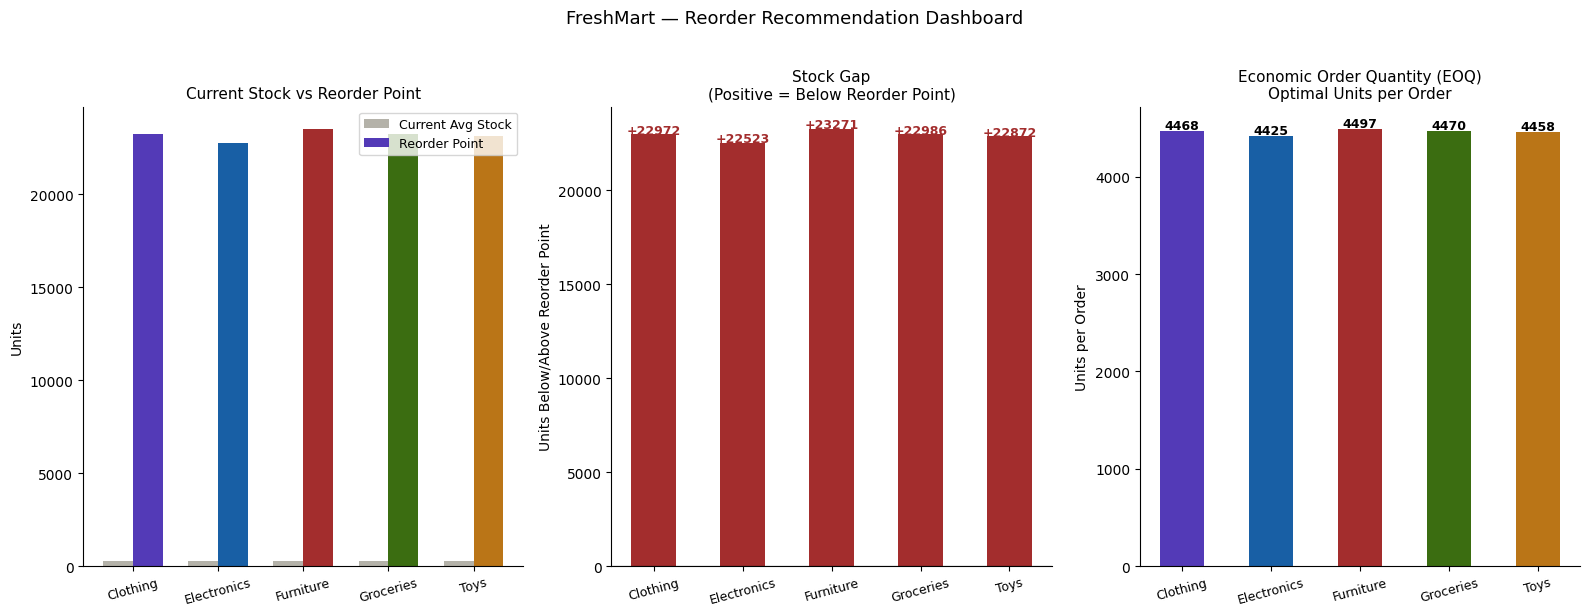

✅ Chart 8 saved


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
colors_list = [cat_colors.get(c, '#444441') for c in reorder_df['Category']]

# Left: Current Stock vs Reorder Point
x = range(len(reorder_df))
width = 0.35
axes[0].bar([i - width/2 for i in x], reorder_df['Current Avg Stock'],
            width=width, color='#B4B2A9', label='Current Avg Stock', edgecolor='none')
axes[0].bar([i + width/2 for i in x], reorder_df['Reorder Point (units)'],
            width=width, color=colors_list, label='Reorder Point', edgecolor='none')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(reorder_df['Category'], rotation=15, fontsize=9)
axes[0].set_title('Current Stock vs Reorder Point', fontsize=11)
axes[0].set_ylabel('Units')
axes[0].legend(fontsize=9)

# Middle: Stock Gap (how much below reorder point)
gap_colors = ['#A32D2D' if g > 0 else '#3B6D11' for g in reorder_df['Stock Gap']]
axes[1].bar(reorder_df['Category'], reorder_df['Stock Gap'],
            color=gap_colors, edgecolor='none', width=0.5)
axes[1].axhline(y=0, color='black', linewidth=0.8)
for i, (cat, val) in enumerate(zip(reorder_df['Category'], reorder_df['Stock Gap'])):
    axes[1].text(i, val + 20, f'{val:+.0f}', ha='center', fontsize=9, fontweight='bold',
                color='#A32D2D' if val > 0 else '#3B6D11')
axes[1].set_title('Stock Gap\n(Positive = Below Reorder Point)', fontsize=11)
axes[1].set_ylabel('Units Below/Above Reorder Point')
axes[1].tick_params(axis='x', rotation=15, labelsize=9)

# Right: EOQ per category
axes[2].bar(reorder_df['Category'], reorder_df['EOQ (units per order)'],
            color=colors_list, edgecolor='none', width=0.5)
for i, (cat, val) in enumerate(zip(reorder_df['Category'], reorder_df['EOQ (units per order)'])):
    axes[2].text(i, val + 20, f'{val:.0f}', ha='center', fontsize=9, fontweight='bold')
axes[2].set_title('Economic Order Quantity (EOQ)\nOptimal Units per Order', fontsize=11)
axes[2].set_ylabel('Units per Order')
axes[2].tick_params(axis='x', rotation=15, labelsize=9)

plt.suptitle('FreshMart — Reorder Recommendation Dashboard', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../data/output/chart8_reorder_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 8 saved")

In [8]:
# Export full reorder report as Excel for stakeholder delivery
excel_path = '../data/output/freshmart_reorder_recommendations.xlsx'

with pd.ExcelWriter(excel_path, engine='xlsxwriter') as writer:
    # Sheet 1: Reorder recommendations
    reorder_df.to_excel(writer, sheet_name='Reorder Recommendations', index=False)

    # Sheet 2: Full forecast data
    all_forecasts = []
    for cat in categories:
        fc = forecasts[cat].copy()
        fc['category'] = cat
        future_only = fc[fc['ds'] > daily_sales['ds'].max()][
            ['ds', 'category', 'yhat', 'yhat_lower', 'yhat_upper']
        ].head(90)
        all_forecasts.append(future_only)

    pd.concat(all_forecasts).to_excel(
        writer, sheet_name='90-Day Forecasts', index=False)

    # Sheet 3: ABC Classification (from Phase 2)
    try:
        abc_df = pd.read_csv('../data/output/abc_classification.csv')
        abc_df.to_excel(writer, sheet_name='ABC Classification', index=False)
    except:
        pass

print(f"✅ Excel report exported → {excel_path}")

# Also save reorder table to DB
conn = sqlite3.connect(DB_PATH)
reorder_df.to_sql('reorder_recommendations', conn, if_exists='replace', index=False)
conn.close()

print("✅ Reorder table saved to database")

✅ Excel report exported → ../data/output/freshmart_reorder_recommendations.xlsx
✅ Reorder table saved to database


In [9]:
print("=" * 65)
print("PHASE 3 COMPLETE — DEMAND FORECASTING SUMMARY")
print("=" * 65)

print(f"\n📊 Models trained: {len(models)} Prophet models (one per category)")
print(f"📅 Forecast horizon: {FORECAST_DAYS} days")
print(f"⚠️  Lead time assumption: {LEAD_TIME_DAYS} days")

print(f"\n{'Category':<15} {'Reorder Point':>14} {'EOQ':>8} {'Status':>14}")
print("-" * 55)
for _, row in reorder_df.iterrows():
    print(f"{row['Category']:<15} {row['Reorder Point (units)']:>14.0f} "
          f"{row['EOQ (units per order)']:>8.0f} {row['Status']:>14}")

print(f"\n📁 Files saved to data/output/:")
import os
for f in sorted(os.listdir('../data/output/')):
    if f != '.gitkeep':
        size = os.path.getsize(f'../data/output/{f}')
        print(f"   → {f}  ({size/1024:.1f} KB)")

print("\n✅ Ready for Power BI Dashboard! 🚀")

PHASE 3 COMPLETE — DEMAND FORECASTING SUMMARY

📊 Models trained: 5 Prophet models (one per category)
📅 Forecast horizon: 90 days
⚠️  Lead time assumption: 7 days

Category         Reorder Point      EOQ         Status
-------------------------------------------------------
Clothing                 23246     4468    REORDER NOW
Electronics              22796     4425    REORDER NOW
Furniture                23547     4497    REORDER NOW
Groceries                23261     4470    REORDER NOW
Toys                     23145     4458    REORDER NOW

📁 Files saved to data/output/:
   → abc_classification.csv  (1.5 KB)
   → chart1_stockout_risk.png  (99.1 KB)
   → chart2_inventory_health.png  (75.4 KB)
   → chart3_revenue_trend.png  (171.0 KB)
   → chart4_inventory_heatmap.png  (156.4 KB)
   → chart5_abc_classification.png  (101.8 KB)
   → chart6_demand_forecasts.png  (1088.8 KB)
   → chart7_seasonality.png  (208.7 KB)
   → chart8_reorder_dashboard.png  (96.1 KB)
   → freshmart_master_reorder_